<div style="text-align: center; font-size: 40px; font-weight: bold;">
    Train Model Deeplabv3+ Architecture
</div>

# Libraries

In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import os
import cv2
from PIL import Image
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint


# Load Data

In [2]:
def map_mask_to_classes(mask_array: np.ndarray) -> np.ndarray:
    """
    Maps a binary mask to class labels.
    
    Args:
        mask_array (np.ndarray): Input mask array.
        
    Returns:
        np.ndarray: Binary mask with values mapped to 0 and 1.
    """
    return (mask_array > 0).astype(np.uint8)

In [3]:
def load_images_and_masks(image_folder: str, mask_folder: str, img_height: int, img_width: int) -> tuple:
    """
    Loads images and masks from specified folders, normalizes images, and processes masks.
    
    Args:
        image_folder (str): Path to the image folder.
        mask_folder (str): Path to the mask folder.
        img_height (int): Target image height.
        img_width (int): Target image width.
        
    Returns:
        tuple: (numpy.ndarray of images, numpy.ndarray of masks)
    """
    images, masks = [], []
    
    image_files = sorted(os.listdir(image_folder))
    mask_files = sorted(os.listdir(mask_folder))
    
    for img_file, mask_file in zip(image_files, mask_files):
        img_path = os.path.join(image_folder, img_file)
        mask_path = os.path.join(mask_folder, mask_file)
        
        # Load and normalize image
        img = load_img(img_path, target_size=(img_height, img_width))
        img = img_to_array(img) / 255.0
        images.append(img)
        
        # Load and process mask
        mask = load_img(mask_path, target_size=(img_height, img_width), color_mode="grayscale")
        mask = img_to_array(mask).astype(np.int32).squeeze()
        masks.append(map_mask_to_classes(mask))
    
    return np.array(images), np.array(masks).reshape(-1, img_height, img_width, 1)


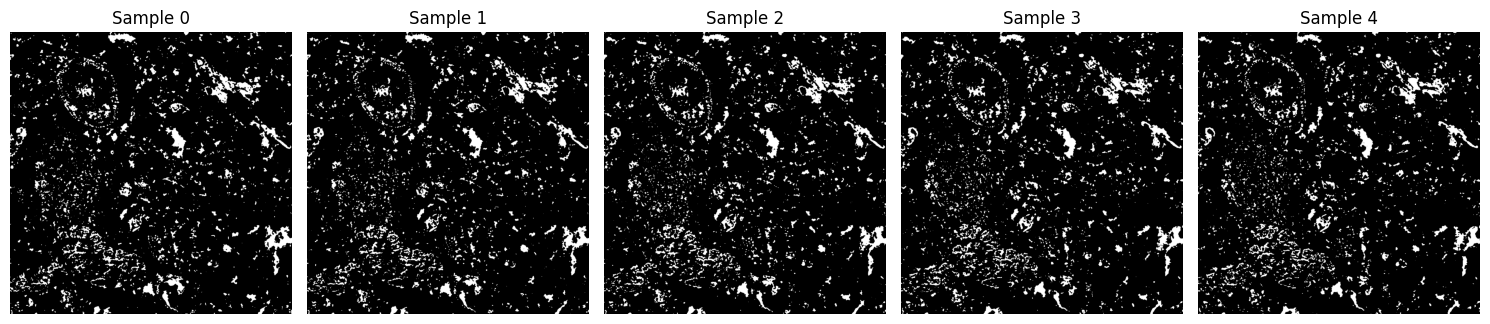

In [4]:
# Folder path
folder_path = "Data_mask"

# Sorted images
image_files = sorted([f for f in os.listdir(folder_path) if f.endswith(".bmp")])

# Select the first five images
selected_images = image_files[:5]

# Show images for horizontal structure form
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

# Looping to call the images
for i, img_name in enumerate(selected_images):
    img_path = os.path.join(folder_path, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)  
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  

    axes[i].imshow(img, cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"Sample {i}")

# Plot the images
plt.tight_layout()
plt.show()

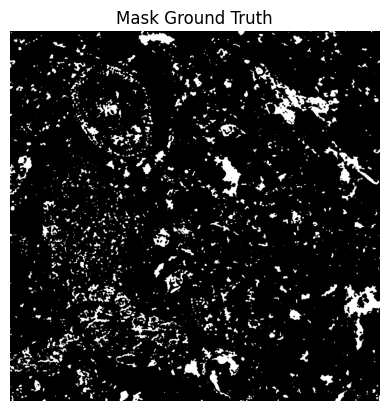

Unique value form masking image: [  0 255]


In [5]:
mask_path = "Data_mask/mask_CLAHE_dlm0000.bmp"
mask = Image.open(mask_path)
plt.imshow(mask, cmap='gray')
plt.title("Mask Ground Truth")
plt.axis('off')
plt.show()

# Check unique value on the mask
mask_array = np.array(mask)
print(f"Unique value form masking image: {np.unique(mask_array)}")

In [6]:
def conv_block(x, filters, k=3, reps=2):
    for _ in range(reps):
        x = layers.Conv2D(filters, k, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)
    return x

def encoder_block(x, filters):
    x = conv_block(x, filters)
    p = layers.MaxPooling2D((2, 2), strides=2)(x)
    return x, p

def decoder_block(x, filters):
    x = layers.UpSampling2D((2, 2), interpolation="nearest")(x)
    x = conv_block(x, filters)
    return x

def SegNet(input_shape=(256, 256, 3), num_classes=1):
    inputs = layers.Input(shape=input_shape)

    # Encoder
    x1, p1 = encoder_block(inputs, 64)
    x2, p2 = encoder_block(p1, 128)
    x3, p3 = encoder_block(p2, 256)
    x4, p4 = encoder_block(p3, 512)
    x5, p5 = encoder_block(p4, 512)

    # Bottleneck
    b = conv_block(p5, 1024)

    # Decoder
    d1 = decoder_block(b, 512)
    d2 = decoder_block(d1, 512)
    d3 = decoder_block(d2, 256)
    d4 = decoder_block(d3, 128)
    d5 = decoder_block(d4, 64)

    # Output
    outputs = layers.Conv2D(num_classes, (1, 1), activation='sigmoid')(d5)

    model = models.Model(inputs, outputs)
    return model


In [7]:
def mean_iou(y_true, y_pred):
    # Konversi probabilitas -> 0/1
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    y_true_bin = tf.cast(y_true > 0.5, tf.float32)

    intersection = tf.reduce_sum(y_true_bin * y_pred_bin)
    union = tf.reduce_sum(y_true_bin) + tf.reduce_sum(y_pred_bin) - intersection + 1e-7

    return intersection / union


# Splitting Dataset

In [8]:
IMG_HEIGHT, IMG_WIDTH = 512, 512 
# Load dataset train and validation
train_images, train_masks = load_images_and_masks('Data_split/train/images', 'Data_split/train/masks', IMG_HEIGHT, IMG_WIDTH)
val_images, val_masks = load_images_and_masks('Data_split/valid/images', 'Data_split/valid/masks', IMG_HEIGHT, IMG_WIDTH)

print(f"Shape train_images: {train_images.shape}")
print(f"Shape train_masks: {train_masks.shape}")

Shape train_images: (595, 512, 512, 3)
Shape train_masks: (595, 512, 512, 1)


In [9]:
model = SegNet(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=1)

model.summary()

2025-10-11 22:06:44.664433: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M2
2025-10-11 22:06:44.664664: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-10-11 22:06:44.664668: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2025-10-11 22:06:44.665785: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-10-11 22:06:44.666435: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 512, 512, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 512, 512, 64)      1728      
                                                                 
 batch_normalization (Batch  (None, 512, 512, 64)      256       
 Normalization)                                                  
                                                                 
 re_lu (ReLU)                (None, 512, 512, 64)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 512, 512, 64)      36864     
                                                                 
 batch_normalization_1 (Bat  (None, 512, 512, 64)      256       
 chNormalization)                                            

In [ ]:
# Kompilasi model
# ======= Kompilasi Model =======
model.compile(optimizer='adam',
              loss="binary_crossentropy",
              metrics=['accuracy', mean_iou])

# ======= Callbacks =======
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

lr_reduce = ReduceLROnPlateau(monitor='val_loss', 
                              factor=0.5, 
                              patience=5, 
                              min_lr=1e-6,
                              verbose=1)

model_checkpoint = ModelCheckpoint('Model/model_unet.h5', 
                                   monitor='val_loss', 
                                   save_best_only=True, 
                                   verbose=1)

callbacks = [early_stop, lr_reduce, model_checkpoint]
# ======= Training Contoh =======
history = model.fit(train_images, train_masks,
                    validation_data=(val_images, val_masks),
                    epochs=100,
                    callbacks=callbacks)

Epoch 1/100


2025-10-11 22:07:01.028401: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


In [ ]:
# Extract data from history.history
epochs = range(1, len(history.history['loss']) + 1)
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
iou = history.history['iou_metric']
val_iou = history.history['val_iou_metric']

# Plotting Training and Validation Accuracy
plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()
plt.grid(True)
plt.show()  # Display accuracy plot

# Plotting Training and Validation Loss
plt.figure()
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and validation loss')
plt.legend()
plt.grid(True)
plt.show()  # Display loss plot

# Plotting Training and Validation IoU
plt.figure()
plt.plot(epochs, iou, 'r', label='Training IoU')
plt.plot(epochs, val_iou, 'b', label='Validation IoU')
plt.title('Training and validation IoU')
plt.legend()
plt.grid(True)
plt.show()  # Display IoU plot

In [ ]:
# Hitung rata-rata untuk setiap metrik
avg_acc = np.mean(history.history['accuracy'])
avg_val_acc = np.mean(history.history['val_accuracy'])

avg_loss = np.mean(history.history['loss'])
avg_val_loss = np.mean(history.history['val_loss'])

avg_iou = np.mean(history.history['iou_metric'])
avg_val_iou = np.mean(history.history['val_iou_metric'])

# Cetak hasil rata-rata
print("=== Average Results Training ===")
print(f"Average Training Accuracy   : {avg_acc:.4f}")
print(f"Average Validation Accuracy : {avg_val_acc:.4f}")
print(f"Average Training Loss       : {avg_loss:.4f}")
print(f"Average Validation Loss     : {avg_val_loss:.4f}")
print(f"Average Training IoU        : {avg_iou:.4f}")
print(f"Average Validation IoU      : {avg_val_iou:.4f}")